In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn mlxtend scipy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
df = pd.read_excel("/content/Online Retail.xlsx")

print(df.head())
print(df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
(541909, 8)


In [ ]:
df.dropna(subset=['CustomerID'], inplace=True)

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [ ]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [ ]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

print(pca.explained_variance_ratio_)

[0.55502102 0.30249315]


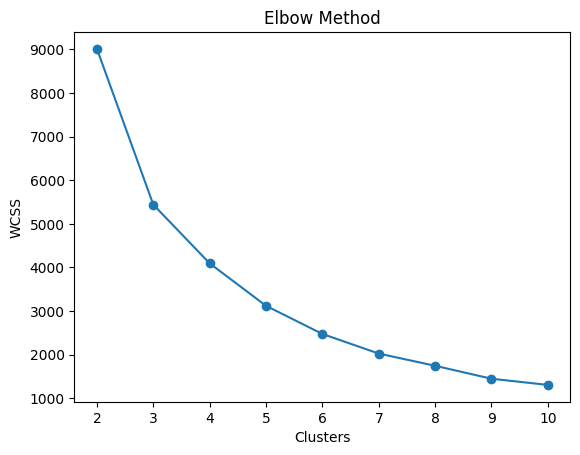

In [ ]:
wcss = []

for i in range(2,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(rfm_scaled)

rfm['KMeans_Cluster'] = clusters

print(rfm.head())

            Recency  Frequency  Monetary  KMeans_Cluster
CustomerID                                              
12346.0         326          1  77183.60               3
12347.0           2          7   4310.00               0
12348.0          75          4   1797.24               0
12349.0          19          1   1757.55               0
12350.0         310          1    334.40               1


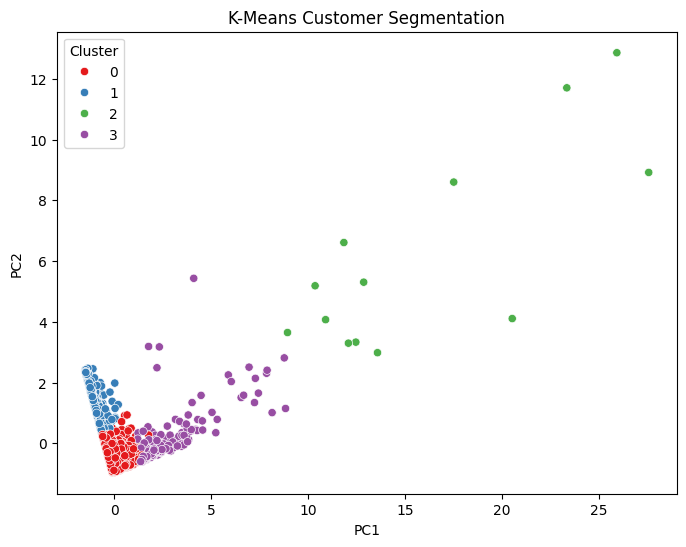

In [ ]:
pca_df['Cluster'] = clusters

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title("K-Means Customer Segmentation")
plt.show()

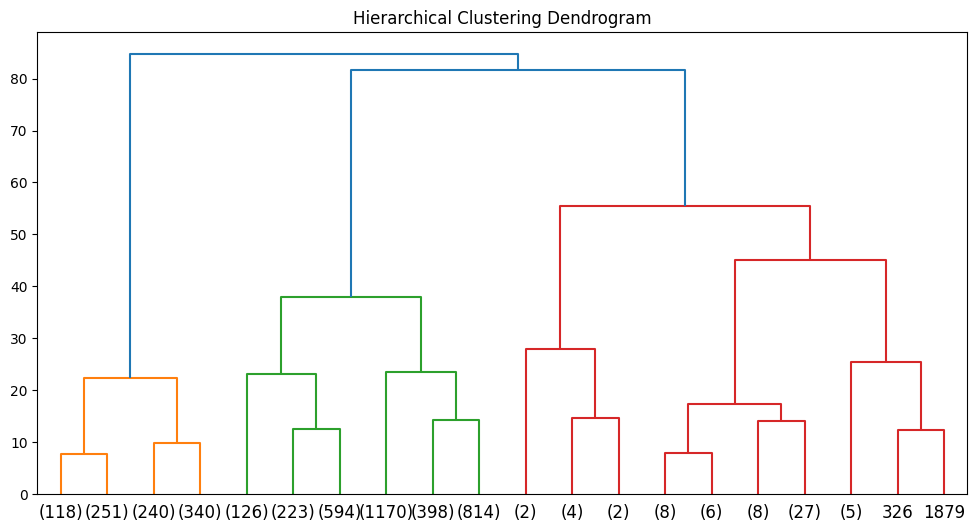

In [ ]:
linked = linkage(
    rfm_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=20
)

plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [ ]:
dbscan = DBSCAN(
    eps=0.7,
    min_samples=5
)

db_labels = dbscan.fit_predict(rfm_scaled)

rfm['DBSCAN_Cluster'] = db_labels

print(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    4293
-1      45
Name: count, dtype: int64


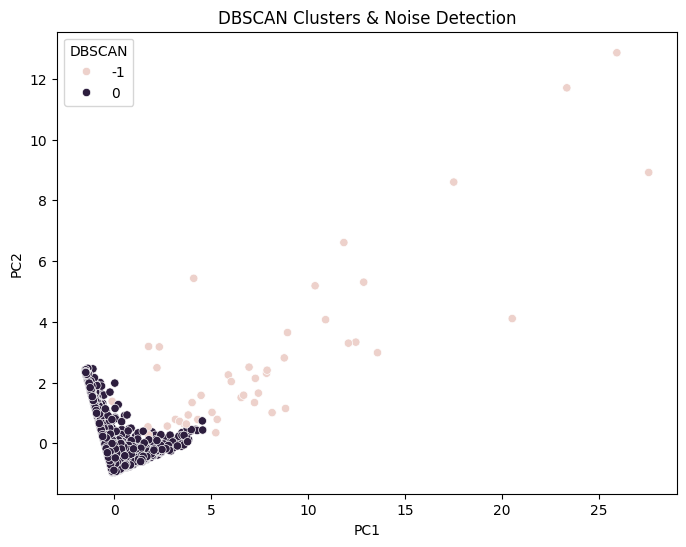

In [ ]:
pca_df['DBSCAN'] = db_labels

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='DBSCAN'
)

plt.title("DBSCAN Clusters & Noise Detection")
plt.show()

In [ ]:
cluster_report = rfm.groupby(
    'KMeans_Cluster'
).mean()

print(cluster_report)

                   Recency  Frequency       Monetary  DBSCAN_Cluster
KMeans_Cluster                                                      
0                43.702685   3.682711    1359.049284       -0.000327
1               248.075914   1.552015     480.617480       -0.000937
2                 7.384615  82.538462  127338.313846       -1.000000
3                15.500000  22.333333   12709.090490       -0.147059


In [ ]:
basket = (df
          .groupby(['InvoiceNo','Description'])['Quantity']
          .sum()
          .unstack()
          .fillna(0))

basket = basket.applymap(
    lambda x: 1 if x > 0 else 0
)

In [ ]:
frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

print(frequent_items.head())

    support                           itemsets
0  0.021692         (3 STRIPEY MICE FELTCRAFT)
1  0.039175           (6 RIBBONS RUSTIC CHARM)
2  0.025146  (60 CAKE CASES VINTAGE CHRISTMAS)
3  0.035452      (60 TEATIME FAIRY CAKE CASES)
4  0.027034   (72 SWEETHEART FAIRY CAKE CASES)


In [ ]:
rules = association_rules(
    frequent_items,
    metric='lift',
    min_threshold=1
)

print(
    rules[['antecedents',
           'consequents',
           'support',
           'confidence',
           'lift']]
)

                                          antecedents  \
0                         (ALARM CLOCK BAKELIKE RED )   
1                        (ALARM CLOCK BAKELIKE GREEN)   
2                         (ALARM CLOCK BAKELIKE RED )   
3                         (ALARM CLOCK BAKELIKE PINK)   
4                              (DOLLY GIRL LUNCH BOX)   
..                                                ...   
71  (PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...   
72  (ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...   
73                   (PINK REGENCY TEACUP AND SAUCER)   
74                 (ROSES REGENCY TEACUP AND SAUCER )   
75                  (GREEN REGENCY TEACUP AND SAUCER)   

                                          consequents   support  confidence  \
0                        (ALARM CLOCK BAKELIKE GREEN)  0.028599    0.604333   
1                         (ALARM CLOCK BAKELIKE RED )  0.028599    0.671736   
2                         (ALARM CLOCK BAKELIKE PINK)  0.021368    0.451539   

In [ ]:
anomalies = rfm[
    rfm['DBSCAN_Cluster'] == -1
]

print("Number of anomalies:")
print(len(anomalies))

Number of anomalies:
45
